2026-06-09 21:05:34,752 - INFO - Ensemble Diagnostics System Configured.
2026-06-09 21:05:34,811 - INFO - Training model...



DIAGNOSTICS SYSTEM PERFORMANCE REPORT

Accuracy: 94.74%

              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



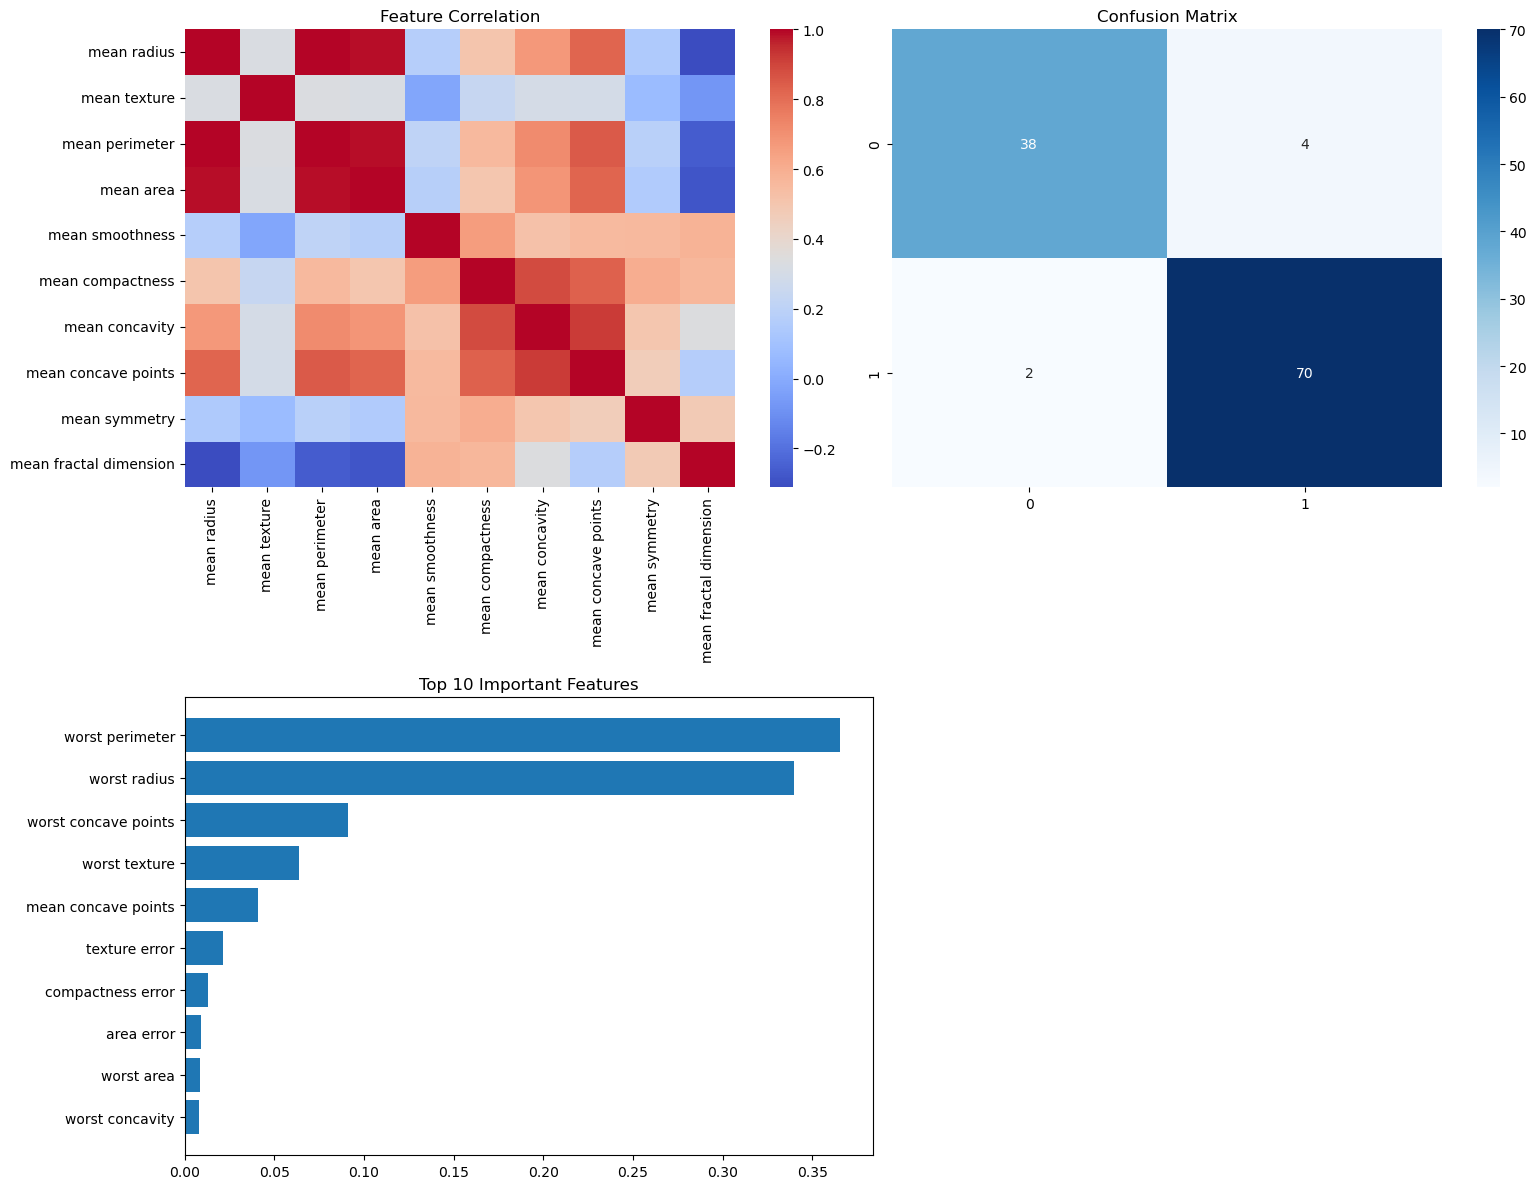

2026-06-09 21:05:46,476 - INFO - Full report saved at: medical_full_report_20260609_210538.png


In [4]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


class MedicalDiagnosticEngine:
    def __init__(self):
        """Initializes optimized Gradient Boosting model."""
        self.model = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.08,
            max_depth=4,
            random_state=42
        )
        logging.info("Ensemble Diagnostics System Configured.")

    def generate_full_report(self, df, X_test, y_test, predictions):
        """Creates full analytics dashboard (SAVE + SHOW)."""

        plt.figure(figsize=(16, 12))

        # -------------------------
        # 1️⃣ Correlation Heatmap
        # -------------------------
        plt.subplot(2, 2, 1)
        corr_matrix = df.iloc[:, :10].corr()
        sns.heatmap(corr_matrix, cmap='coolwarm')
        plt.title("Feature Correlation")

        # -------------------------
        # 2️⃣ Confusion Matrix
        # -------------------------
        plt.subplot(2, 2, 2)
        cm = confusion_matrix(y_test, predictions)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix")

        # -------------------------
        # 3️⃣ Feature Importance
        # -------------------------
        plt.subplot(2, 2, 3)
        importances = self.model.feature_importances_
        indices = np.argsort(importances)[-10:]

        plt.barh(range(len(indices)), importances[indices])
        plt.yticks(range(len(indices)), df.columns[indices])
        plt.title("Top 10 Important Features")

        plt.tight_layout()

        # -------------------------
        # 💾 Save + Show
        # -------------------------
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        file_path = f"medical_full_report_{timestamp}.png"

        plt.savefig(file_path, dpi=300)   # SAVE in main folder
        plt.show()                        # SHOW after output
        plt.close()

        logging.info(f"Full report saved at: {file_path}")


def main():
    # -------------------------
    # 📊 Load Dataset
    # -------------------------
    raw_data = load_breast_cancer()
    X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
    y = raw_data.target

    engine = MedicalDiagnosticEngine()

    # -------------------------
    # Split Data
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    logging.info("Training model...")
    engine.model.fit(X_train, y_train)

    predictions = engine.model.predict(X_test)

    # -------------------------
    # 📋 Performance Report
    # -------------------------
    print("\n" + "="*60)
    print("DIAGNOSTICS SYSTEM PERFORMANCE REPORT")
    print("="*60)

    print(f"\nAccuracy: {accuracy_score(y_test, predictions)*100:.2f}%\n")

    print(classification_report(
        y_test,
        predictions,
        target_names=raw_data.target_names
    ))

    # -------------------------
    # 📈 Generate Full Report
    # -------------------------
    engine.generate_full_report(X, X_test, y_test, predictions)


if __name__ == "__main__":
    main()

In [7]:
from sklearn.datasets import load_breast_cancer

raw_data = load_breast_cancer()